In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ee
import os
import requests
from PIL import Image
from io import BytesIO
import imageio
import json
import numpy as np
import pandas as pd
from time import sleep
from datetime import datetime, timedelta
from os import listdir
from os.path import isfile, join
import shutil
import logging
import csv

In [3]:
#prior to running any earth engine code, you must authenticate
#ONLY NEEDS TO RUN ONCE
ee.Authenticate()

True

In [4]:
#initialize the earth engine
ee.Initialize(project='ee-sebastian-internship')

c:\Users\sebgr\.conda\envs\CF_Intern\Lib\site-packages\ee\deprecation.py:137: UserWarning: Unable to initialize deprecated assets: Remote end closed connection without response
  warnings.warn(f'Unable to initialize deprecated assets: {e}')


Here the function to integrate NDVI

In [15]:
# Set up logging configuration
logging.basicConfig(level=logging.INFO)

def calculate_ndvi(image):
    """Calculate NDVI for a given image"""
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return ndvi

def get_composite_fao1(adm, start_date, end_date, cloud=30, scale=400, mask_water=False, adm_level=0, cape_town=False):
    """Get composite Landsat8 image for a given region from images collected within a timeframe"""
    
    # Call landsat and geometry
    l8 = ee.ImageCollection("LANDSAT/LC08/C01/T1_SR")
    
    # Read layer with country boundaries, then extract specific country
    if adm_level == 0:
        countries = ee.FeatureCollection('FAO/GAUL/2015/level0')
        geometry = countries.filter(f'ADM0_CODE=={adm}').geometry()
    elif adm_level == 1:
        countries = ee.FeatureCollection('FAO/GAUL/2015/level1')
        geometry = countries.filter(f'ADM1_CODE=={adm}').geometry()
    elif adm_level == 2:
        countries = ee.FeatureCollection('FAO/GAUL/2015/level2')
        geometry = countries.filter(f'ADM2_CODE=={adm}').geometry()

    # If the region is Cape Town, apply the bounding box
    if cape_town:
        bbox = ee.Geometry.Rectangle([18.2, -36, 19.5, -32])  # Adjust coordinates as needed
        geometry = geometry.intersection(bbox, ee.ErrorMargin(1))

    # Get dataset for location and date range
    dataset = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate(start_date, end_date).filterBounds(geometry).filter(f'CLOUD_COVER < {cloud}')

    # Mask clouds out
    dataset = dataset.map(mask_clouds_landsat8)
      
    # Calculate NDVI
    dataset = dataset.map(calculate_ndvi)
    
    # Flatten image collection into a single image as the median value for each pixel
    im = dataset.median()
    
    # Deal with oceans
    if mask_water:
        hansenImage = ee.Image('UMD/hansen/global_forest_change_2015')
        datamask = hansenImage.select('datamask')
        watermask = datamask.eq(1)
        im = im.updateMask(watermask)
    
    # Limit output to geometry polygon
    geo_mask = ee.Image.constant(1).clip(geometry).mask()
    im = im.updateMask(geo_mask)
    
    try:
        # Attempt to get export URL
        url = im.getThumbURL({
            'name': 'NDVI',
            'bands': ['NDVI'],
            'min': -1.0,
            'max': 1.0,
            'region': geometry,
            'scale': scale,
            'format': 'png',
            'filePerBand': False,
            'crs': 'EPSG:3857'
        })
        logging.info(f"Generated URL: {url}")
        return url
    
    except ee.EEException as e:
        # Handle the exception gracefully
        logging.error("An error occurred while generating thumbnail URL: %s", e)
        return None

def mask_clouds_landsat8(image):
    """Mask clouds from Landsat8 image collection.
    See https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2 for qa_pixel bitmask in Landsat 8"""
    cloudShadowBitMask = (1 << 4)
    cloudsBitMask = (1 << 3)
    qa = image.select('QA_PIXEL')
    shadow_mask = qa.bitwiseAnd(cloudShadowBitMask).eq(0)
    cloud_mask = qa.bitwiseAnd(cloudsBitMask).eq(0)
    masked_image = image.updateMask(cloud_mask)
    masked_image = masked_image.updateMask(shadow_mask)
    masked_image = masked_image.copyProperties(image, image.propertyNames())
    return masked_image

def applyScaleFactors(image):
    """Convert RGB landsat 8 bands into 'true colors'"""
    opticalBands = image.select(['SR_B4', 'SR_B3', 'SR_B2']).multiply(0.0000275).add(-0.2)
    thermalBands = image.select(['ST_B10']).multiply(0.00341802).add(149.0)
    image = image.addBands(opticalBands, None, True).addBands(thermalBands, None, True)
    return image

def apply_colormap(image_array, cmap='RdYlGn'):
    """Apply a colormap to a grayscale image array."""
    norm = plt.Normalize(vmin=-1, vmax=1)
    colormap = plt.get_cmap(cmap)
    colored_image = colormap(norm(image_array))
    return (colored_image[:, :, :3] * 255).astype(np.uint8)

def download_image(url, pname, fname):
    """Downloads image from earth-engine generated url and saves it within the project folder"""
    if url is None:
        logging.error("No URL provided, skipping download.")
        return
    
    retries = 3
    for attempt in range(retries):
        try:
            os.makedirs(f"output/output_ndvi/{pname}", exist_ok=True)
            logging.info(f"Attempting to download image from URL: {url}")
            response = requests.get(url, timeout=10)
            response.raise_for_status()  # Raise an error on bad status
            img = Image.open(BytesIO(response.content)).convert('L')
            img_array = np.array(img) / 255.0 * 2 - 1  # Normalize to -1 to 1 NDVI range
            colored_image = apply_colormap(img_array)
            img_colored = Image.fromarray(colored_image)
            img_colored.save(f"output/output_ndvi/{pname}/{fname}.png")
            logging.info(f"Successfully downloaded and saved image: {fname}")
            break  # Exit loop if successful
        except requests.exceptions.RequestException as e:
            logging.error(f"Error downloading image: {e}")
            if attempt < retries - 1:
                logging.info("Retrying...")
                sleep(2)  # Wait before retrying
            else:
                logging.error("Failed to download image after several attempts")

def download_image_timespan(pname, adm, adm_level, start, end, scale=200, mask_water=False, cape_town=False):
    """Download images over a timespan for a specific region"""
    # Loop through years and months
    for year in range(start, end + 1):
        for month in range(1, 13):
            d0 = f'{year}-{month:02d}-01'
            d1 = (datetime.strptime(d0, '%Y-%m-%d') + timedelta(days=30)).strftime('%Y-%m-%d')
            start_date = datetime.strptime(d0, '%Y-%m-%d')
            end_date = datetime.strptime(d1, '%Y-%m-%d')

            # Get the composite for the url
            url = get_composite_fao1(adm, start_date, end_date, cloud=40, scale=scale, adm_level=adm_level, mask_water=mask_water, cape_town=cape_town)
            
            if url is not None:
                # Create subfolder for year and month
                subfolder = f"{pname}/{year}/{month:02d}"
                os.makedirs(f"output/output_ndvi/{subfolder}", exist_ok=True)
                
                # Download image
                download_image(url, subfolder, f"{pname}_{d0}")
            else:
                logging.error(f"Failed to generate URL for {start_date} to {end_date}")

# Define parameters
pname = 'City of Cape Town Metropolitan Municipality'
adm = 77317  # Code for country, check codes here https://www.fao.org/in-action/countrystat/news-and-events/events/training-material/gaul-codes2014/en/
adm_level = 2  # 0 for country, 1 for region, 2 for department

start_year = 2015
end_year = 2023

download_image_timespan(pname, adm, adm_level, start_year, end_year, mask_water=False, scale=200, cape_town=True)


INFO:root:Generated URL: https://earthengine.googleapis.com/v1/projects/ee-sebastian-internship/thumbnails/70c9994d0e99ccec54452473c2afd6a4-fcdd2742b29156029b69fb8590277184:getPixels
INFO:root:Attempting to download image from URL: https://earthengine.googleapis.com/v1/projects/ee-sebastian-internship/thumbnails/70c9994d0e99ccec54452473c2afd6a4-fcdd2742b29156029b69fb8590277184:getPixels
INFO:root:Successfully downloaded and saved image: City of Cape Town Metropolitan Municipality_2015-01-01
INFO:root:Generated URL: https://earthengine.googleapis.com/v1/projects/ee-sebastian-internship/thumbnails/ff9ba212b0d5a64d45eb3bc4e350853d-f09b1ec451bfdddedc38c9ef307e6314:getPixels
INFO:root:Attempting to download image from URL: https://earthengine.googleapis.com/v1/projects/ee-sebastian-internship/thumbnails/ff9ba212b0d5a64d45eb3bc4e350853d-f09b1ec451bfdddedc38c9ef307e6314:getPixels
INFO:root:Successfully downloaded and saved image: City of Cape Town Metropolitan Municipality_2015-02-01
INFO:roo

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

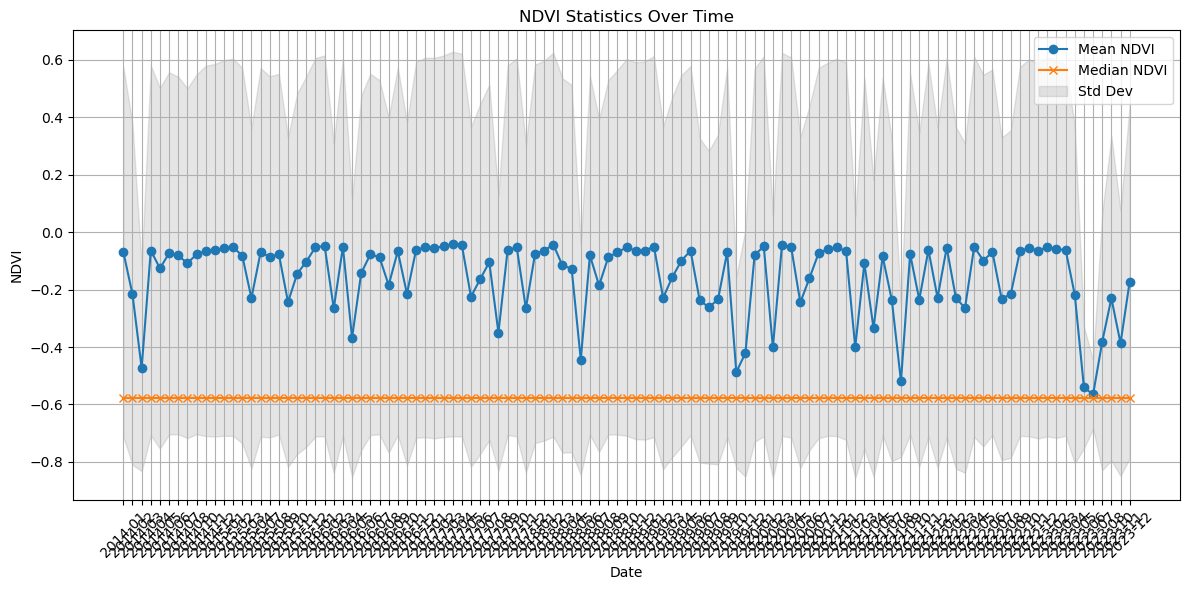

In [16]:
def analyze_ndvi_statistics(image_folder, pname, start_year, end_year):
    """Analyze NDVI statistics over time from downloaded images and save to CSV"""
    ndvi_means = []
    ndvi_medians = []
    ndvi_stds = []
    dates = []

    output_csv = f"output/0_output_csv/{pname}_ndvi_statistics.csv"
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)

    with open(output_csv, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Date', 'Mean_NDVI', 'Median_NDVI', 'Std_Dev_NDVI'])

        # Iterate over downloaded images
        for year in range(start_year, end_year + 1):
            for month in range(1, 13):
                folder_path = f"{image_folder}/{year}/{month:02d}"
                
                if not os.path.exists(folder_path):
                    continue

                for img_file in os.listdir(folder_path):
                    if img_file.endswith(".png"):
                        img_path = os.path.join(folder_path, img_file)
                        img = Image.open(img_path).convert('L')
                        img_array = np.array(img) / 255.0 * 2 - 1  # Normalize to -1 to 1 NDVI range
                        mean_ndvi = np.mean(img_array)
                        median_ndvi = np.median(img_array)
                        std_ndvi = np.std(img_array)

                        date = f"{year}-{month:02d}"
                        writer.writerow([date, mean_ndvi, median_ndvi, std_ndvi])

                        # Append to lists for plotting if needed
                        ndvi_means.append(mean_ndvi)
                        ndvi_medians.append(median_ndvi)
                        ndvi_stds.append(std_ndvi)
                        dates.append(date)

    # Plot NDVI statistics over time
    plt.figure(figsize=(12, 6))
    plt.plot(dates, ndvi_means, label='Mean NDVI', marker='o')
    plt.plot(dates, ndvi_medians, label='Median NDVI', marker='x')
    plt.fill_between(dates, np.array(ndvi_means) - np.array(ndvi_stds), np.array(ndvi_means) + np.array(ndvi_stds), color='gray', alpha=0.2, label='Std Dev')
    plt.xlabel('Date')
    plt.ylabel('NDVI')
    plt.title('NDVI Statistics Over Time')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Define the folder where the images are saved
image_folder = "output/output_ndvi/City of Cape Town Metropolitan Municipality"
pname = "City of Cape Town Metropolitan Municipality"
start_year = 2014
end_year = 2023

# Run the analysis and save to CSV
analyze_ndvi_statistics(image_folder, pname, start_year, end_year)